In [5]:
# Import Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [6]:
excel_file = 'SupplyChainEmissionFactorsforUSIndustriesCommodities.xlsx'  # Replace with actual path
years = range(2010, 2017)

In [7]:
years[2]

2012

In [8]:
df_1 = pd.read_excel(excel_file, sheet_name=f'{years[0]}_Detail_Commodity')
df_1.head()

,Commodity Code,Commodity Name,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Unnamed: 7,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins
0,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",carbon dioxide,"kg/2018 USD, purchaser price",0.398,0.073,0.470,NaN,4,3,1,4,1
1,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",methane,"kg/2018 USD, purchaser price",0.001,0.001,0.002,NaN,4,3,1,1,1
2,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",nitrous oxide,"kg/2018 USD, purchaser price",0.002,0.000,0.002,NaN,4,3,1,4,1
3,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",other GHGs,"kg CO2e/2018 USD, purchaser price",0.002,0.000,0.002,NaN,3,3,1,3,1
4,1111B0,"Fresh wheat, corn, rice, and other grains",carbon dioxide,"kg/2018 USD, purchaser price",0.659,0.081,0.740,NaN,4,3,1,4,1


In [9]:
df_2 = pd.read_excel(excel_file, sheet_name=f'{years[0]}_Detail_Industry')
df_2.head()


,Industry Code,Industry Name,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Unnamed: 7,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins
0,1111A0,Oilseed farming,carbon dioxide,"kg/2018 USD, purchaser price",0.414,0.073,0.487,NaN,4,3,1,4,1
1,1111A0,Oilseed farming,methane,"kg/2018 USD, purchaser price",0.001,0.001,0.002,NaN,4,3,1,1,1
2,1111A0,Oilseed farming,nitrous oxide,"kg/2018 USD, purchaser price",0.002,0.000,0.002,NaN,4,3,1,4,1
3,1111A0,Oilseed farming,other GHGs,"kg CO2e/2018 USD, purchaser price",0.002,0.000,0.002,NaN,3,3,1,3,1
4,1111B0,Grain farming,carbon dioxide,"kg/2018 USD, purchaser price",0.680,0.082,0.762,NaN,4,3,1,4,1


In [10]:
all_data = []

for year in years:
    try:
        df_com = pd.read_excel(excel_file, sheet_name=f'{year}_Detail_Commodity')
        df_ind = pd.read_excel(excel_file, sheet_name=f'{year}_Detail_Industry')

        df_com['Source'] = 'Commodity'
        df_ind['Source'] = 'Industry'
        df_com['Year'] = df_ind['Year'] = year

        df_com.columns = df_com.columns.str.strip()
        df_ind.columns = df_ind.columns.str.strip()

        df_com.rename(columns={
            'Commodity Code': 'Code',
            'Commodity Name': 'Name'
        }, inplace=True)

        df_ind.rename(columns={
            'Industry Code': 'Code',
            'Industry Name': 'Name'
        }, inplace=True)

        all_data.append(pd.concat([df_com, df_ind], ignore_index=True))

    except Exception as e:
        print(f"Error processing year {year}: {e}")

In [11]:
all_data[3]

,Code,Name,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Unnamed: 7,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Source,Year
0,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",carbon dioxide,"kg/2018 USD, purchaser price",0.373,0.072,0.444,NaN,4,3,1,4,1,Commodity,2013
1,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",methane,"kg/2018 USD, purchaser price",0.001,0.001,0.002,NaN,4,3,1,1,1,Commodity,2013
2,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",nitrous oxide,"kg/2018 USD, purchaser price",0.002,0.000,0.002,NaN,4,3,1,4,1,Commodity,2013
3,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",other GHGs,"kg CO2e/2018 USD, purchaser price",0.002,0.000,0.002,NaN,3,3,1,4,1,Commodity,2013
4,1111B0,"Fresh wheat, corn, rice, and other grains",carbon dioxide,"kg/2018 USD, purchaser price",0.722,0.079,0.801,NaN,4,3,1,4,1,Commodity,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3151,813B00,"Civic, social, professional, and similar organ...",other GHGs,"kg CO2e/2018 USD, purchaser price",0.008,0.000,0.008,NaN,4,3,1,5,1,Industry,2013
3152,814000,Private households,carbon dioxide,"kg/2018 USD, purchaser price",0.000,0.000,0.000,NaN,4,3,1,5,1,Industry,2013
3153,814000,Private households,methane,"kg/2018 USD, purchaser price",0.000,0.000,0.000,NaN,4,3,1,5,1,Industry,2013
3154,814000,Private households,nitrous oxide,"kg/2018 USD, purchaser price",0.000,0.000,0.000,NaN,4,3,1,5,1,Industry,2013


In [12]:
len(all_data)

7

In [13]:
df = pd.concat(all_data, ignore_index=True)
df.head(10)

,Code,Name,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Unnamed: 7,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Source,Year
0,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",carbon dioxide,"kg/2018 USD, purchaser price",0.398,0.073,0.470,NaN,4,3,1,4,1,Commodity,2010
1,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",methane,"kg/2018 USD, purchaser price",0.001,0.001,0.002,NaN,4,3,1,1,1,Commodity,2010
2,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",nitrous oxide,"kg/2018 USD, purchaser price",0.002,0.000,0.002,NaN,4,3,1,4,1,Commodity,2010
3,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",other GHGs,"kg CO2e/2018 USD, purchaser price",0.002,0.000,0.002,NaN,3,3,1,3,1,Commodity,2010
4,1111B0,"Fresh wheat, corn, rice, and other grains",carbon dioxide,"kg/2018 USD, purchaser price",0.659,0.081,0.740,NaN,4,3,1,4,1,Commodity,2010
5,1111B0,"Fresh wheat, corn, rice, and other grains",methane,"kg/2018 USD, purchaser price",0.008,0.001,0.009,NaN,2,3,1,1,1,Commodity,2010
6,1111B0,"Fresh wheat, corn, rice, and other grains",nitrous oxide,"kg/2018 USD, purchaser price",0.004,0.000,0.004,NaN,4,3,1,4,1,Commodity,2010
7,1111B0,"Fresh wheat, corn, rice, and other grains",other GHGs,"kg CO2e/2018 USD, purchaser price",0.004,0.000,0.004,NaN,3,3,1,3,1,Commodity,2010
8,111200,"Fresh vegetables, melons, and potatoes",carbon dioxide,"kg/2018 USD, purchaser price",0.183,0.132,0.315,NaN,3,3,1,4,1,Commodity,2010
9,111200,"Fresh vegetables, melons, and potatoes",methane,"kg/2018 USD, purchaser price",0.001,0.001,0.002,NaN,4,3,1,1,1,Commodity,2010


In [14]:
df

,Code,Name,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,Unnamed: 7,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Source,Year
0,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",carbon dioxide,"kg/2018 USD, purchaser price",0.398,0.073,0.470,NaN,4,3,1,4,1,Commodity,2010
1,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",methane,"kg/2018 USD, purchaser price",0.001,0.001,0.002,NaN,4,3,1,1,1,Commodity,2010
2,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",nitrous oxide,"kg/2018 USD, purchaser price",0.002,0.000,0.002,NaN,4,3,1,4,1,Commodity,2010
3,1111A0,"Fresh soybeans, canola, flaxseeds, and other o...",other GHGs,"kg CO2e/2018 USD, purchaser price",0.002,0.000,0.002,NaN,3,3,1,3,1,Commodity,2010
4,1111B0,"Fresh wheat, corn, rice, and other grains",carbon dioxide,"kg/2018 USD, purchaser price",0.659,0.081,0.740,NaN,4,3,1,4,1,Commodity,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22087,813B00,"Civic, social, professional, and similar organ...",other GHGs,"kg CO2e/2018 USD, purchaser price",0.009,0.000,0.009,NaN,4,2,1,5,1,Industry,2016
22088,814000,Private households,carbon dioxide,"kg/2018 USD, purchaser price",0.000,0.000,0.000,NaN,4,2,1,5,1,Industry,2016
22089,814000,Private households,methane,"kg/2018 USD, purchaser price",0.000,0.000,0.000,NaN,4,2,1,5,1,Industry,2016
22090,814000,Private households,nitrous oxide,"kg/2018 USD, purchaser price",0.000,0.000,0.000,NaN,4,2,1,5,1,Industry,2016


In [15]:
df.columns # Checking columns

Index(['Code', 'Name', 'Substance', 'Unit',
       'Supply Chain Emission Factors without Margins',
       'Margins of Supply Chain Emission Factors',
       'Supply Chain Emission Factors with Margins', 'Unnamed: 7',
       'DQ ReliabilityScore of Factors without Margins',
       'DQ TemporalCorrelation of Factors without Margins',
       'DQ GeographicalCorrelation of Factors without Margins',
       'DQ TechnologicalCorrelation of Factors without Margins',
       'DQ DataCollection of Factors without Margins', 'Source', 'Year'],
      dtype='object')

In [16]:
df.isnull().sum()

Code                                                          0
Name                                                          0
Substance                                                     0
Unit                                                          0
Supply Chain Emission Factors without Margins                 0
Margins of Supply Chain Emission Factors                      0
Supply Chain Emission Factors with Margins                    0
Unnamed: 7                                                22092
DQ ReliabilityScore of Factors without Margins                0
DQ TemporalCorrelation of Factors without Margins             0
DQ GeographicalCorrelation of Factors without Margins         0
DQ TechnologicalCorrelation of Factors without Margins        0
DQ DataCollection of Factors without Margins                  0
Source                                                        0
Year                                                          0
dtype: int64

In [17]:
# # As there is no data avaialble in Unnamed coulmn so we will drop the column
df.drop(columns=['Unnamed: 7'],inplace=True)

In [18]:
print(df.info())   # Checking data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 14 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Code                                                    22092 non-null  object 
 1   Name                                                    22092 non-null  object 
 2   Substance                                               22092 non-null  object 
 3   Unit                                                    22092 non-null  object 
 4   Supply Chain Emission Factors without Margins           22092 non-null  float64
 5   Margins of Supply Chain Emission Factors                22092 non-null  float64
 6   Supply Chain Emission Factors with Margins              22092 non-null  float64
 7   DQ ReliabilityScore of Factors without Margins          22092 non-null  int64  
 8   DQ TemporalCorrelation of Factors wi

In [19]:
df.describe().T # Checking summary statistics

,count,mean,std,min,25%,50%,75%,max
Supply Chain Emission Factors without Margins,22092.0,0.084807,0.267039,0.0,0.0,0.002,0.044,7.228
Margins of Supply Chain Emission Factors,22092.0,0.012857,0.078720,0.0,0.0,0.000,0.000,3.349
Supply Chain Emission Factors with Margins,22092.0,0.097681,0.288992,0.0,0.0,0.003,0.052,7.290
DQ ReliabilityScore of Factors without Margins,22092.0,3.308030,0.499643,2.0,3.0,3.000,4.000,4.000
DQ TemporalCorrelation of Factors without Margins,22092.0,2.571429,0.494883,2.0,2.0,3.000,3.000,3.000
DQ GeographicalCorrelation of Factors without Margins,22092.0,1.000000,0.000000,1.0,1.0,1.000,1.000,1.000
DQ TechnologicalCorrelation of Factors without Margins,22092.0,2.632129,1.135661,1.0,1.0,3.000,3.000,5.000
DQ DataCollection of Factors without Margins,22092.0,1.000000,0.000000,1.0,1.0,1.000,1.000,1.000
Year,22092.0,2013.000000,2.000045,2010.0,2011.0,2013.000,2015.000,2016.000


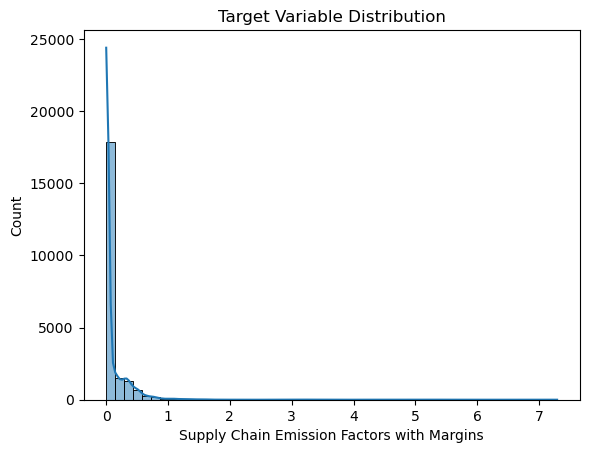

In [20]:
# Visualize distribution
sns.histplot(df['Supply Chain Emission Factors with Margins'], bins=50, kde=True)
plt.title('Target Variable Distribution')
plt.show()

In [21]:
# Check categorical variables
print(df['Substance'].value_counts())

Substance
carbon dioxide    5523
methane           5523
nitrous oxide     5523
other GHGs        5523
Name: count, dtype: int64


In [22]:
print(df['Unit'].value_counts()) # Checking unique values in 'Unit' with count

Unit
kg/2018 USD, purchaser price         16569
kg CO2e/2018 USD, purchaser price     5523
Name: count, dtype: int64


In [23]:
print(df['Unit'].unique()) # Checking unique values in 'Unit'

['kg/2018 USD, purchaser price' 'kg CO2e/2018 USD, purchaser price']


In [24]:
print(df['Source'].value_counts()) # Checking unique values in 'Source' with count

Source
Industry     11060
Commodity    11032
Name: count, dtype: int64


In [25]:
df['Substance'].unique() # Checking unique values in 'Substance'

array(['carbon dioxide', 'methane', 'nitrous oxide', 'other GHGs'],
      dtype=object)

In [26]:
substance_map={'carbon dioxide':0, 'methane':1, 'nitrous oxide':2, 'other GHGs':3} # Mapping substances to integers

In [27]:
df['Substance']=df['Substance'].map(substance_map)

In [28]:
df['Substance'].unique() # Checking unique values in 'Substance'

array([0, 1, 2, 3])

In [29]:
print(df['Unit'].unique()) # Checking unique values in 'Unit'

['kg/2018 USD, purchaser price' 'kg CO2e/2018 USD, purchaser price']


In [30]:
unit_map={'kg/2018 USD, purchaser price':0, 'kg CO2e/2018 USD, purchaser price':1} # Mapping units to integers

In [31]:
df['Unit']=df['Unit'].map(unit_map)

In [32]:
print(df['Unit'].unique()) # Checking unique values in 'Unit'

[0 1]


In [33]:
print(df['Source'].unique()) # Checking unique values in 'Source


['Commodity' 'Industry']


In [34]:
source_map={'Commodity':0, 'Industry':1} 

In [35]:
df['Source']=df['Source'].map(source_map)   # applying the mapping to 'Source' column

In [36]:
print(df['Source'].unique()) # Checking unique values in 'Source

[0 1]


In [37]:
df.info() # Checking data types and non-null counts after mapping

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 14 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Code                                                    22092 non-null  object 
 1   Name                                                    22092 non-null  object 
 2   Substance                                               22092 non-null  int64  
 3   Unit                                                    22092 non-null  int64  
 4   Supply Chain Emission Factors without Margins           22092 non-null  float64
 5   Margins of Supply Chain Emission Factors                22092 non-null  float64
 6   Supply Chain Emission Factors with Margins              22092 non-null  float64
 7   DQ ReliabilityScore of Factors without Margins          22092 non-null  int64  
 8   DQ TemporalCorrelation of Factors wi

In [38]:
df.Code.unique() # Checking unique values in 'Code' df['Code']

array(['1111A0', '1111B0', '111200', '111300', '111400', '111900',
       '112120', '1121A0', '112300', '112A00', '113000', '114000',
       '115000', '211000', '212100', '212230', '2122A0', '212310',
       '2123A0', '213111', '21311A', '221100', '221200', '221300',
       '230301', '230302', '233210', '233230', '233240', '233262',
       '2332A0', '2332C0', '2332D0', '233411', '233412', '2334A0',
       '311111', '311119', '311210', '311221', '311224', '311225',
       '311230', '311300', '311410', '311420', '311513', '311514',
       '31151A', '311520', '311615', '31161A', '311700', '311810',
       '3118A0', '311910', '311920', '311930', '311940', '311990',
       '312110', '312120', '312130', '312140', '312200', '313100',
       '313200', '313300', '314110', '314120', '314900', '315000',
       '316000', '321100', '321200', '321910', '3219A0', '322110',
       '322120', '322130', '322210', '322220', '322230', '322291',
       '322299', '323110', '323120', '324110', '324121', '3241

In [39]:
df.Name.unique() # Checking unique values in 'Name'

array(['Fresh soybeans, canola, flaxseeds, and other oilseeds',
       'Fresh wheat, corn, rice, and other grains',
       'Fresh vegetables, melons, and potatoes',
       'Fresh fruits and tree nuts',
       'Greenhouse crops, mushrooms, nurseries, and flowers',
       'Tobacco, cotton, sugarcane, peanuts, sugar beets, herbs and spices, and other crops',
       'Dairies', 'Cattle ranches and feedlots', 'Poultry farms',
       'Animal farms and aquaculture ponds (except cattle and poultry)',
       'Timber and raw forest products', 'Wild-caught fish and game',
       'Agriculture and forestry support', 'Unrefined oil and gas',
       'Coal', 'Copper, nickel, lead, and zinc',
       'Iron, gold, silver, and other metal ores', 'Dimensional stone',
       'Sand, gravel, clay, phosphate, other nonmetallic minerals',
       'Well drilling', 'Other support activities for mining',
       'Electricity', 'Natural gas',
       'Drinking water and wastewater treatment',
       'Nonresidential mai

In [40]:
#Top 10 Emmiting Industry

In [41]:
top_emitters = df[['Name', 'Supply Chain Emission Factors with Margins']].groupby('Name').mean().sort_values(
    'Supply Chain Emission Factors with Margins', ascending=False).head(10)

# Resetting index for better plotting
top_emitters = top_emitters.reset_index()
top_emitters

,Name,Supply Chain Emission Factors with Margins
0,Cement manufacturing,1.686179
1,Cement,1.324964
2,"Electric power generation, transmission, and d...",1.220357
3,Electricity,1.016143
4,"Dolls, toys, and games",0.832179
5,Lime and gypsum products,0.816536
6,Lime and gypsum product manufacturing,0.799679
7,Industrial gas manufacturing,0.612929
8,Compressed Gases,0.539679
9,Clothing,0.468714


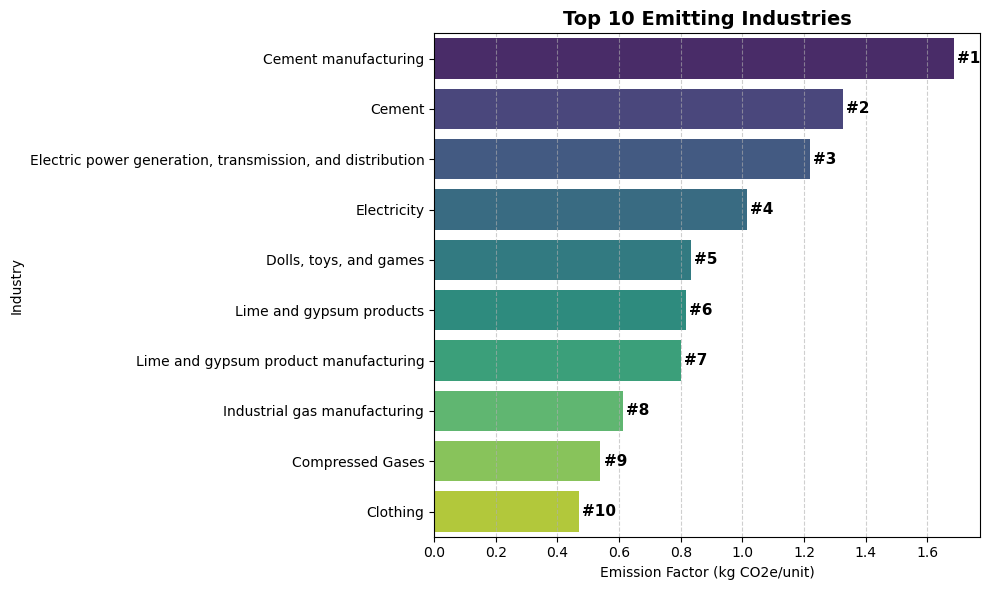

In [42]:
# Plotting the top 10 emitting industries


plt.figure(figsize=(10,6))
# Example: Top emitting industries (already grouped)
sns.barplot(
    x='Supply Chain Emission Factors with Margins',
    y='Name',
    data=top_emitters,
    hue='Name',
    palette='viridis'  # Use 'Blues', 'viridis', etc., for other color maps
)

# Add ranking labels (1, 2, 3...) next to bars
for i, (value, name) in enumerate(zip(top_emitters['Supply Chain Emission Factors with Margins'], top_emitters.index), start=1):
    plt.text(value + 0.01, i - 1, f'#{i}', va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Top 10 Emitting Industries', fontsize=14, fontweight='bold') # Title of the plot
plt.xlabel('Emission Factor (kg CO2e/unit)') # X-axis label
plt.ylabel('Industry') # Y-axis label
plt.grid(axis='x', linestyle='--', alpha=0.6) # Adding grid lines for better readability
plt.tight_layout() # Adjust layout to prevent overlap

plt.show()

In [43]:
#Drop non-numeric columns not needed,
#Also drop Code and Year columns since there is no need of both of the column

In [44]:
df.drop(columns=['Name','Code','Year'], inplace=True)
df.head(1)

,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Source
0,0,0,0.398,0.073,0.47,4,3,1,4,1,0


In [45]:
df.shape

(22092, 11)

In [46]:
df.columns

Index(['Substance', 'Unit', 'Supply Chain Emission Factors without Margins',
       'Margins of Supply Chain Emission Factors',
       'Supply Chain Emission Factors with Margins',
       'DQ ReliabilityScore of Factors without Margins',
       'DQ TemporalCorrelation of Factors without Margins',
       'DQ GeographicalCorrelation of Factors without Margins',
       'DQ TechnologicalCorrelation of Factors without Margins',
       'DQ DataCollection of Factors without Margins', 'Source'],
      dtype='object')

In [47]:
#Define features and target

X = df.drop(columns=['Supply Chain Emission Factors with Margins']) # Feature set excluding the target variable
y = df['Supply Chain Emission Factors with Margins'] # Target variable

In [48]:
X.head()

,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Source
0,0,0,0.398,0.073,4,3,1,4,1,0
1,1,0,0.001,0.001,4,3,1,1,1,0
2,2,0,0.002,0.000,4,3,1,4,1,0
3,3,1,0.002,0.000,3,3,1,3,1,0
4,0,0,0.659,0.081,4,3,1,4,1,0


In [49]:
y.head()

0    0.470
1    0.002
2    0.002
3    0.002
4    0.740
Name: Supply Chain Emission Factors with Margins, dtype: float64

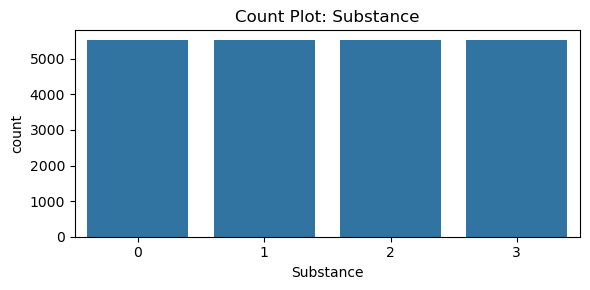

In [50]:
# Count plot for Substance
plt.figure(figsize=(6, 3))
sns.countplot(x=df["Substance"])
plt.title("Count Plot: Substance")
plt.xticks()
plt.tight_layout()
plt.show()

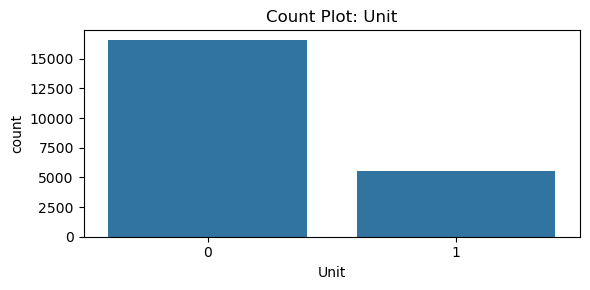

In [51]:
# Count plot for Unit
plt.figure(figsize=(6, 3))
sns.countplot(x=df["Unit"])
plt.title("Count Plot: Unit")
plt.tight_layout()
plt.show()

In [52]:
#Multivariate Anslysis
#Correlation heatmap

df.select_dtypes(include=np.number).corr() # Checking correlation between numerical features

,Substance,Unit,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,DQ ReliabilityScore of Factors without Margins,DQ TemporalCorrelation of Factors without Margins,DQ GeographicalCorrelation of Factors without Margins,DQ TechnologicalCorrelation of Factors without Margins,DQ DataCollection of Factors without Margins,Source
Substance,1.000000e+00,7.745967e-01,-0.391851,-0.218400,-0.421603,0.095092,-3.667637e-15,NaN,0.198415,NaN,4.273306e-16
Unit,7.745967e-01,1.000000e+00,-0.155859,-0.094300,-0.169741,-0.025159,-3.173071e-17,NaN,0.286990,NaN,-1.545892e-17
Supply Chain Emission Factors without Margins,-3.918505e-01,-1.558594e-01,1.000000,0.143005,0.962971,-0.098000,9.283870e-03,NaN,0.148410,NaN,2.713112e-02
Margins of Supply Chain Emission Factors,-2.184002e-01,-9.429989e-02,0.143005,1.000000,0.404541,-0.069598,7.953109e-03,NaN,0.086335,NaN,-6.750426e-02
Supply Chain Emission Factors with Margins,-4.216032e-01,-1.697410e-01,0.962971,0.404541,1.000000,-0.109494,1.074848e-02,NaN,0.160574,NaN,6.687828e-03
DQ ReliabilityScore of Factors without Margins,9.509190e-02,-2.515938e-02,-0.098000,-0.069598,-0.109494,1.000000,-2.170715e-02,NaN,0.073583,NaN,-1.228726e-02
DQ TemporalCorrelation of Factors without Margins,-3.667637e-15,-3.173071e-17,0.009284,0.007953,0.010748,-0.021707,1.000000e+00,NaN,-0.030607,NaN,-2.909814e-15
DQ GeographicalCorrelation of Factors without Margins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DQ TechnologicalCorrelation of Factors without Margins,1.984154e-01,2.869901e-01,0.148410,0.086335,0.160574,0.073583,-3.060675e-02,NaN,1.000000,NaN,2.827202e-02
DQ DataCollection of Factors without Margins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
df.info() # Checking data types and non-null counts after mapping

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 11 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Substance                                               22092 non-null  int64  
 1   Unit                                                    22092 non-null  int64  
 2   Supply Chain Emission Factors without Margins           22092 non-null  float64
 3   Margins of Supply Chain Emission Factors                22092 non-null  float64
 4   Supply Chain Emission Factors with Margins              22092 non-null  float64
 5   DQ ReliabilityScore of Factors without Margins          22092 non-null  int64  
 6   DQ TemporalCorrelation of Factors without Margins       22092 non-null  int64  
 7   DQ GeographicalCorrelation of Factors without Margins   22092 non-null  int64  
 8   DQ TechnologicalCorrelation of Facto

[codecarbon INFO @ 19:34:03] Energy consumed for RAM : 0.000045 kWh. RAM Power : 10.0 W


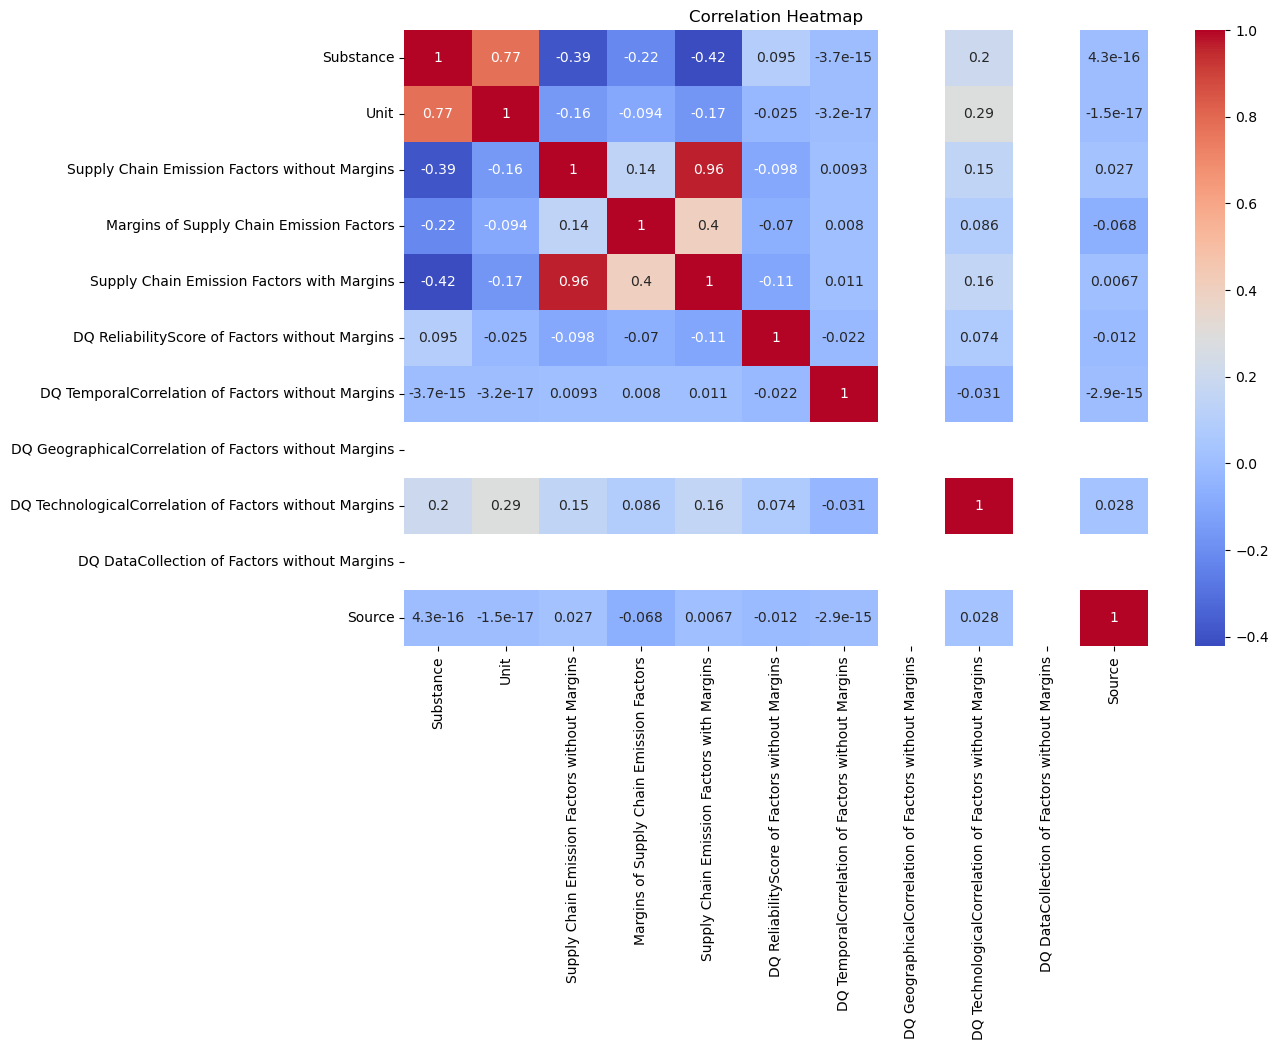

In [54]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [55]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Substance,22092.0,1.500000,1.118059,0.0,0.75,1.500,2.250,3.000
Unit,22092.0,0.250000,0.433023,0.0,0.00,0.000,0.250,1.000
Supply Chain Emission Factors without Margins,22092.0,0.084807,0.267039,0.0,0.00,0.002,0.044,7.228
Margins of Supply Chain Emission Factors,22092.0,0.012857,0.078720,0.0,0.00,0.000,0.000,3.349
DQ ReliabilityScore of Factors without Margins,22092.0,3.308030,0.499643,2.0,3.00,3.000,4.000,4.000
DQ TemporalCorrelation of Factors without Margins,22092.0,2.571429,0.494883,2.0,2.00,3.000,3.000,3.000
DQ GeographicalCorrelation of Factors without Margins,22092.0,1.000000,0.000000,1.0,1.00,1.000,1.000,1.000
DQ TechnologicalCorrelation of Factors without Margins,22092.0,2.632129,1.135661,1.0,1.00,3.000,3.000,5.000
DQ DataCollection of Factors without Margins,22092.0,1.000000,0.000000,1.0,1.00,1.000,1.000,1.000
Source,22092.0,0.500634,0.500011,0.0,0.00,1.000,1.000,1.000


In [56]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [57]:
X_scaled[0].min(),X_scaled[0].max()

(np.float64(-1.3416407864998738), np.float64(1.3849614361966764))

In [58]:
np.round(X_scaled.mean()),np.round(X_scaled.std())

(np.float64(-0.0), np.float64(1.0))

In [59]:
# Step 2: Convert scaled array back to DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Step 3: View statistical summary of all scaled features
summary = X_scaled_df.describe().T.round(3)  # .T transposes the output for better viewing

# Step 4: Print the summary
print(summary)

                                                      count  mean  std    min  \
Substance                                           22092.0   0.0  1.0 -1.342   
Unit                                                22092.0  -0.0  1.0 -0.577   
Supply Chain Emission Factors without Margins       22092.0   0.0  1.0 -0.318   
Margins of Supply Chain Emission Factors            22092.0  -0.0  1.0 -0.163   
DQ ReliabilityScore of Factors without Margins      22092.0   0.0  1.0 -2.618   
DQ TemporalCorrelation of Factors without Margins   22092.0  -0.0  1.0 -1.155   
DQ GeographicalCorrelation of Factors without M...  22092.0   0.0  0.0  0.000   
DQ TechnologicalCorrelation of Factors without ...  22092.0   0.0  1.0 -1.437   
DQ DataCollection of Factors without Margins        22092.0   0.0  0.0  0.000   
Source                                              22092.0  -0.0  1.0 -1.001   

                                                      25%    50%    75%  \
Substance                        

In [60]:
X.shape

(22092, 10)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42) # Splitting data into training and testing sets

In [62]:
print(X_train.shape)
X_test.shape

(17673, 10)


(4419, 10)

In [63]:
#Select the model for training
from sklearn.linear_model import LinearRegression # Importing Linear Regression model
LR_model = LinearRegression() # Initializing Linear Regression model
# Fitting the Linear Regression model on training data

LR_model.fit(X_train, y_train)

LR_y_pred = LR_model.predict(X_test) # Making predictions on the test set using Linear Regression model


LR_mse = mean_squared_error(y_test, LR_y_pred) # Calculating Mean Squared Error (MSE) for Linear Regression model
LR_rmse = np.sqrt(LR_mse) # Calculating Root Mean Squared Error (RMSE) for Linear Regression model
LR_r2 = r2_score(y_test, LR_y_pred) # Calculating R² score for Linear Regression model

print(f'RMSE: {LR_rmse}')
print(f'R² Score: {LR_r2}')

[codecarbon INFO @ 19:34:04] Delta energy consumed for CPU with cpu_load : 0.000022 kWh, power : 4.9150707111 W
[codecarbon INFO @ 19:34:04] Energy consumed for All CPU : 0.000022 kWh


RMSE: 0.00028073792916326844
R² Score: 0.9999985968848819


[codecarbon INFO @ 19:34:04] Monitoring GPUs with indices: [0] out of 1 total GPUs


[codecarbon INFO @ 19:34:04] Energy consumed for all GPUs : 0.000005 kWh. Total GPU Power : 0.9944240041863258 W
[codecarbon INFO @ 19:34:04] 0.000071 kWh of electricity and 0.000000 L of water were used since the beginning.


In [64]:
#Selecting Random Forest

from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor(random_state=42) # Initializing Random Forest Regressor
RF_model.fit(X_train, y_train) # Fitting the model on training data
RF_y_pred = RF_model.predict(X_test) # Making predictions on the test set
RF_mse = mean_squared_error(y_test, RF_y_pred) # Calculating Mean Squared Error (MSE)
RF_rmse = np.sqrt(RF_mse) # Calculating Root Mean Squared Error (RMSE)
# Calculating R² score
RF_r2 = r2_score(y_test, RF_y_pred)

print(f'RMSE: {RF_rmse}')
print(f'R² Score: {RF_r2}')

RMSE: 0.006143789217304181
R² Score: 0.9993280085696331


In [65]:
#--Checking for overfitting in Linear Regression--
# Predict on training and test data
y_train_pred = LR_model.predict(X_train)
y_test_pred = LR_model.predict(X_test)

# RMSE
from sklearn.metrics import mean_squared_error, r2_score
train_rmse = mean_squared_error(y_train, y_train_pred)
test_rmse = mean_squared_error(y_test, y_test_pred)

# R² Score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train RMSE: 7.742547119270457e-08
Test RMSE: 7.881378487088032e-08
Train R2: 0.9999991428854423
Test R2: 0.9999985968848819


In [66]:
#Checking for overfitting in Random Forest
# Predict on training and test data
y_train_pred = RF_model.predict(X_train)
y_test_pred = RF_model.predict(X_test)

# RMSE
from sklearn.metrics import mean_squared_error, r2_score
train_rmse = mean_squared_error(y_train, y_train_pred)
test_rmse = mean_squared_error(y_test, y_test_pred)

# R² Score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train RMSE: 1.196122611873023e-05
Test RMSE: 3.774614594666312e-05
Train R2: 0.9998675869726601
Test R2: 0.9993280085696331


In [67]:
# Hyperparameter tuning for Random Forest Regressor using GridSearchCV
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Perform grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)

# Fit the grid search model on the training data
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

[codecarbon INFO @ 19:34:18] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:34:19] Delta energy consumed for CPU with cpu_load : 0.000150 kWh, power : 37.2304703964375 W
[codecarbon INFO @ 19:34:19] Energy consumed for All CPU : 0.000172 kWh
[codecarbon INFO @ 19:34:19] Energy consumed for all GPUs : 0.000009 kWh. Total GPU Power : 1.0640080806991303 W
[codecarbon INFO @ 19:34:19] 0.000266 kWh of electricity and 0.000000 L of water were used since the beginning.


Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [68]:
# Use the best model to make predictions on the test set
y_pred_best = best_model.predict(X_test)
HP_mse = mean_squared_error(y_test, y_pred_best)
HP_rmse = np.sqrt(HP_mse)
HP_r2 = r2_score(y_test, y_pred_best)

print(f'RMSE: {HP_rmse}')
print(f'R² Score: {HP_r2}')

RMSE: 0.005948528382514106
R² Score: 0.9993700440298772


In [69]:
# Create a comparative DataFrame for all models
results = {
    'Model': ['Random Forest (Default)', 'Linear Regression', 'Random Forest (Tuned)'],
    'MSE': [RF_mse, LR_mse, HP_mse],
    'RMSE': [RF_rmse, LR_rmse, HP_rmse],
    'R2': [RF_r2, LR_r2, HP_r2]
}

# Create a DataFrame to compare the results of different models
comparison_df = pd.DataFrame(results)
print(comparison_df)

                     Model           MSE      RMSE        R2
0  Random Forest (Default)  3.774615e-05  0.006144  0.999328
1        Linear Regression  7.881378e-08  0.000281  0.999999
2    Random Forest (Tuned)  3.538499e-05  0.005949  0.999370


In [70]:
# Create a directory to save the models if it doesn't exist
# !mkdir models

In [71]:
#CodeCarbon use for emission tracker
# %pip install codecarbon


In [72]:
from codecarbon import EmissionsTracker


In [73]:
import os
os.makedirs("emissions", exist_ok=True)

In [74]:
# Start carbon emission tracker
tracker_lr = EmissionsTracker(
    project_name="Linear_Regression_Model",
    output_dir="emissions",
    output_file="linear_regression_emissions.csv"
)
tracker_lr.start()

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Stop tracker
emissions_lr = tracker_lr.stop()

# Results
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("CO₂ Emissions (kg):", emissions_lr)

[codecarbon WARNING @ 19:34:23] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:34:25] [setup] RAM Tracking...
[codecarbon INFO @ 19:34:25] [setup] CPU Tracking...
[codecarbon WARNING @ 19:34:25] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:34:25] CPU Model on constant consumption mode: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon WARNING @ 19:34:25] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:34:25] [setup] GPU Tracking...
[codecarbon INFO @ 19:34:25] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:34:25] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 19:34:25] >>> Tracker's metadata:
[co

Linear Regression MSE: 7.881378487088032e-08
CO₂ Emissions (kg): 3.1328290646709956e-06


In [75]:
# Start tracker
tracker_rf = EmissionsTracker(
    project_name="Random_Forest_Model",
    output_dir="emissions",
    output_file="random_forest_emissions.csv"
)
tracker_rf.start()

# Train model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Stop tracker
emissions_rf = tracker_rf.stop()

# Results
print("Random Forest MSE :", mean_squared_error(y_test, y_pred_rf))
print("CO₂ Emissions (kg):", emissions_rf)


[codecarbon WARNING @ 19:34:31] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:34:32] [setup] RAM Tracking...
[codecarbon INFO @ 19:34:32] [setup] CPU Tracking...
[codecarbon WARNING @ 19:34:32] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:34:32] CPU Model on constant consumption mode: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon WARNING @ 19:34:32] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:34:32] [setup] GPU Tracking...
[codecarbon INFO @ 19:34:32] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:34:32] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 19:34:32] >>> Tracker's metadata:
[co

Random Forest MSE : 3.7746145946663054e-05
CO₂ Emissions (kg): 4.145520485266422e-06


In [76]:
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

In [77]:
tracker_ann = EmissionsTracker(
    project_name="Nural_network_Model",
    output_dir="emissions",
    output_file="Nural_network_emissions.csv"
)
tracker_ann.start()

# Train model
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(128,activation='relu',bias_initializer='zero',kernel_initializer='ones'))

ann.add(tf.keras.layers.Dense(64,activation='relu'))

ann.add(tf.keras.layers.Dense(1,activation='sigmoid'))
ann.compile(optimizer=Adam(
    learning_rate=0.5),loss='categorical_crossentropy',metrics=['accuracy'])
ann.fit(X_train, y_train,epochs=20)

# Predict
y_pred_ann = ann.predict(X_test)

# Stop tracker
emissions_ann = tracker_ann.stop()
del tracker_ann
# Results
print("ANN MSE :", mean_squared_error(y_test, y_pred_ann))
print("CO₂ Emissions (kg):", emissions_ann)

[codecarbon WARNING @ 19:34:38] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:34:39] [setup] RAM Tracking...
[codecarbon INFO @ 19:34:39] [setup] CPU Tracking...
[codecarbon WARNING @ 19:34:39] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:34:39] CPU Model on constant consumption mode: AMD Ryzen 5 5600H with Radeon Graphics
[codecarbon WARNING @ 19:34:39] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:34:39] [setup] GPU Tracking...
[codecarbon INFO @ 19:34:39] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:34:39] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 19:34:39] >>> Tracker's metadata:
[co

Epoch 1/20


c:\Users\theex\anaconda3\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


553/553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2782 - loss: 0.0000e+00  
Epoch 2/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 3/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 982us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 4/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 5/20
358/553 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.2768 - loss: 0.0000e+00

[codecarbon INFO @ 19:34:48] Energy consumed for RAM : 0.000165 kWh. RAM Power : 10.0 W


553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2783 - loss: 0.0000e+00  
Epoch 6/20
320/553 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.2704 - loss: 0.0000e+00

[codecarbon INFO @ 19:34:49] Delta energy consumed for CPU with cpu_load : 0.000020 kWh, power : 4.97226828515625 W
[codecarbon INFO @ 19:34:49] Energy consumed for All CPU : 0.000224 kWh
[codecarbon INFO @ 19:34:49] Energy consumed for all GPUs : 0.000018 kWh. Total GPU Power : 1.062326451659889 W
[codecarbon INFO @ 19:34:49] 0.000407 kWh of electricity and 0.000000 L of water were used since the beginning.


553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 7/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 8/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2783 - loss: 0.0000e+00  
Epoch 9/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 10/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 11/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2783 - loss: 0.0000e+00  
Epoch 12/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2783 - loss: 0.0000e+00  
Epoch 13/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 14/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 15/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.2783 - loss: 0.0000e+00
Epoch 16/20
553/553 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step - accuracy: 0.2783 - loss: 0.0

[codecarbon INFO @ 19:34:57] Energy consumed for RAM : 0.000039 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:34:58] Delta energy consumed for CPU with cpu_load : 0.000020 kWh, power : 5.036266587461539 W
[codecarbon INFO @ 19:34:58] Energy consumed for All CPU : 0.000020 kWh
[codecarbon INFO @ 19:34:58] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 19:34:58] Energy consumed for all GPUs : 0.000004 kWh. Total GPU Power : 0.9894451965937654 W
[codecarbon INFO @ 19:34:58] 0.000063 kWh of electricity and 0.000000 L of water were used since the beginning.


ANN MSE : 0.06432888866259334
CO₂ Emissions (kg): 4.477511189838279e-05


In [78]:
print(f"Linear Regression CO₂ Emissions: {emissions_lr:.8f} kg")
print(f"Random Forest CO₂ Emissions: {emissions_rf:.8f} kg")
print(f"ANN CO₂ Emissions: {emissions_ann:.8f} kg")


Linear Regression CO₂ Emissions: 0.00000313 kg
Random Forest CO₂ Emissions: 0.00000415 kg
ANN CO₂ Emissions: 0.00004478 kg


In [ ]:
# Save model
# Linear Model
joblib.dump(LR_model, 'models/LR_model.pkl')    # Save the best model
joblib.dump(scaler, 'models/scaler.pkl') # Save the scaler used for normalization

['models/scaler.pkl']

[codecarbon INFO @ 19:35:03] Energy consumed for RAM : 0.000206 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:35:04] Delta energy consumed for CPU with cpu_load : 0.000019 kWh, power : 4.78242950653125 W
[codecarbon INFO @ 19:35:04] Energy consumed for All CPU : 0.000243 kWh
[codecarbon INFO @ 19:35:04] Energy consumed for all GPUs : 0.000022 kWh. Total GPU Power : 1.0675338170082405 W
[codecarbon INFO @ 19:35:04] 0.000471 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 19:35:18] Energy consumed for RAM : 0.000246 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 19:35:19] Delta energy consumed for CPU with cpu_load : 0.000018 kWh, power : 4.5293410096875 W
[codecarbon INFO @ 19:35:19] Energy consumed for All CPU : 0.000262 kWh
[codecarbon INFO @ 19:35:19] Energy consumed for all GPUs : 0.000027 kWh. Total GPU Power : 1.0660548559443512 W
[codecarbon INFO @ 19:35:19] 0.000534 kWh of electricity and 0.000000 L of water were used since the beginning.